In [1]:
import pandas as pd, numpy as np, os
from db_queries import get_population, get_covariate_estimates, get_outputs, get_ids
import vivarium.artifact as artifact

In [2]:
location = 'india'


l = get_ids('location')
location_id = l.loc[l.location_name==location.title()].location_id.values[0]
results_dir = '/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.1.1/maternal/rice/india/2026_09_02_12_59_56/results/'
# results_dir = results_dir + location + '/'
# now get most recent timestep for specified location
# results_dir = results_dir + sorted(os.listdir(results_dir))[len(os.listdir(results_dir))-1] + '/results/'
# artifact_dir = '/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/legacy_1.0/maternal/nigeria.hdf'
artifact_dir = f'/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1.1/maternal/rice/india.hdf'
results_dir

'/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.1.1/maternal/rice/india/2026_09_02_12_59_56/results/'

# first just maternal outputs

In [3]:
year_id=2023
age_group_ids = list(range(7,17))
asfr = get_covariate_estimates(covariate_id=13, 
                               location_id=location_id, 
                               age_group_id=age_group_ids,
                               sex_id=2,
                               release_id=16,
                               year_id=year_id).rename(columns={'mean_value':'val'})
sbr = get_covariate_estimates(covariate_id=2267, 
                               location_id=location_id, 
                               release_id=16,
                               year_id=year_id).rename(columns={'mean_value':'val'})
incidence_c995 = get_outputs(topic='cause',
                             release_id=16,
                            year_id=2023,
                            cause_id=995,
                            sex_id=2,
                            location_id=location_id,
                            age_group_id=age_group_ids,
                            measure_id=6,
                            metric_id=3,
                            #compare_version_id=7948
                            )
incidence_c374 = get_outputs(topic='cause',
                            release_id=16,
                            year_id=2023,
                            cause_id=374,
                            sex_id=2,
                            location_id=location_id,
                            age_group_id=age_group_ids,
                            measure_id=6,
                            metric_id=3,
                            #compare_version_id=7948
                            )
live_inc = asfr.set_index(['location_id','age_group_id'])[['val']]
still_inc = (asfr.set_index(['location_id','age_group_id'])[['val']]
               * sbr.set_index(['location_id'])[['val']])
other_inc = (incidence_c995.set_index(['location_id','age_group_id'])[['val']]
             + incidence_c374.set_index(['location_id','age_group_id'])[['val']])
preg_inc = (asfr.set_index(['location_id','age_group_id'])[['val']]
            + (asfr.set_index(['location_id','age_group_id'])[['val']]
               * sbr.set_index(['location_id'])[['val']])
            + incidence_c995.set_index(['location_id','age_group_id'])[['val']]
            + incidence_c374.set_index(['location_id','age_group_id'])[['val']])
frac_live = (live_inc / preg_inc).dropna()
frac_still = (still_inc / preg_inc).dropna()
frac_other = (other_inc / preg_inc).dropna()
frac_other.head()

val
location_id age_group_id          
163         7             0.249384
            8             0.150782
            9             0.103945
            10            0.091566
            11            0.093680

In [4]:
# load up pregnancy incidence
art = artifact.Artifact(artifact_dir, filter_terms=['sex==Female', 'age_start >= 10', 'age_end <=55'])
asfr = art.load('covariate.age_specific_fertility_rate.estimate')
sbr = art.load('covariate.stillbirth_28_weeks_to_live_birth_ratio.estimate')   # GBD 2023 split the covariate into 20/28-week variants; model 1.1 carries the 28-week one
inc_mis = art.load('cause.maternal_abortion_and_miscarriage.raw_incidence_rate')
inc_ect = art.load('cause.ectopic_pregnancy.raw_incidence_rate')
art_preg_inc = (asfr 
               + asfr * sbr.value.values[0]
               + inc_mis 
               + inc_ect)
trans = pd.read_parquet(results_dir + 'transition_count_pregnancy')
art_live_frac = (asfr / art_preg_inc)[[f'draw_{x}' for x in trans.input_draw.unique()]].mean(axis=1)
art_still_frac = ((asfr * sbr.value.values[0]) / art_preg_inc)[[f'draw_{x}' for x in trans.input_draw.unique()]].mean(axis=1)
art_other_frac = ((inc_mis + inc_ect) / art_preg_inc)[[f'draw_{x}' for x in trans.input_draw.unique()]].mean(axis=1)
art_other_frac.head()

sex     age_start  age_end  year_start  year_end
Female  10.0       15.0     2023        2024        0.229079
        15.0       20.0     2023        2024        0.149638
        20.0       25.0     2023        2024        0.103558
        25.0       30.0     2023        2024        0.091281
        30.0       35.0     2023        2024        0.093891
dtype: float64

In [5]:
# are birth outcomes being counted every timestep or once per sim?
outcomes = pd.read_parquet(results_dir + 'pregnancy_outcome_count')
outcomes = outcomes.groupby(['scenario','input_draw'])['value'].sum() / 500_000 # population size per draw... note this could/should be updated to be read in from the model spec/branches file
assert np.all(outcomes == 1), "Count of pregnancy outcomes does not correspond to expected population size"
# looks great! now being counted once in the same way that the intervention counts are below

In [6]:
cols = ['scenario','age_group','input_draw']
outcomes = pd.read_parquet(results_dir + 'pregnancy_outcome_count')
outcomes = (outcomes.groupby(cols + ['sub_entity'])['value'].sum()
            / outcomes.groupby(cols)['value'].sum()).reset_index()
outcomes = outcomes.loc[outcomes.scenario=='baseline']
outcomes = outcomes.groupby([c for c in cols if c != 'input_draw']
                           + ['sub_entity'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
outcomes.head()

,scenario,age_group,sub_entity,count,mean,std,min,2.5%,50%,97.5%,max
0,baseline,10_to_14,partial_term,1.0,0.244224,NaN,0.244224,0.244224,0.244224,0.244224,0.244224
1,baseline,10_to_14,live_birth,1.0,0.749175,NaN,0.749175,0.749175,0.749175,0.749175,0.749175
2,baseline,10_to_14,stillbirth,1.0,0.006601,NaN,0.006601,0.006601,0.006601,0.006601,0.006601
3,baseline,15_to_19,partial_term,1.0,0.151472,NaN,0.151472,0.151472,0.151472,0.151472,0.151472
4,baseline,15_to_19,live_birth,1.0,0.833950,NaN,0.833950,0.833950,0.833950,0.833950,0.833950


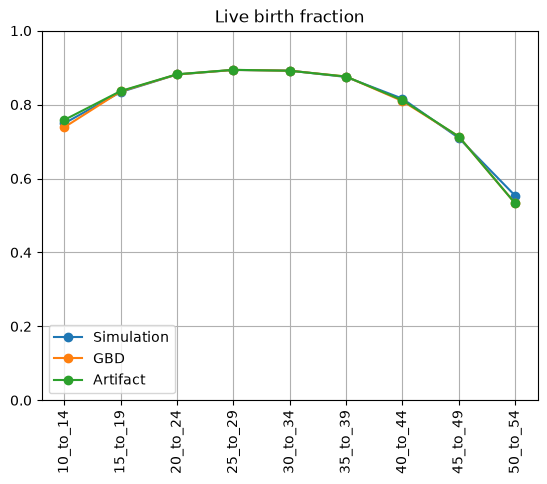

In [7]:
import matplotlib.pyplot as plt

p = outcomes.loc[outcomes.sub_entity=='live_birth']
plt.plot(p.age_group, p['mean'], marker='o', label='Simulation')
plt.fill_between(p.age_group, p['2.5%'], p['97.5%'], alpha=0.2)

plt.plot(p.age_group.iloc[:9], frac_live.reset_index().val, marker='o', label='GBD')
plt.plot(p.age_group.iloc[:9], art_live_frac, marker='o', label='Artifact')
plt.title('Live birth fraction')
plt.xticks(rotation=90)
plt.legend()
plt.ylim(0, 1)
plt.grid()

# don't remember why the artifact and GBD differ here...

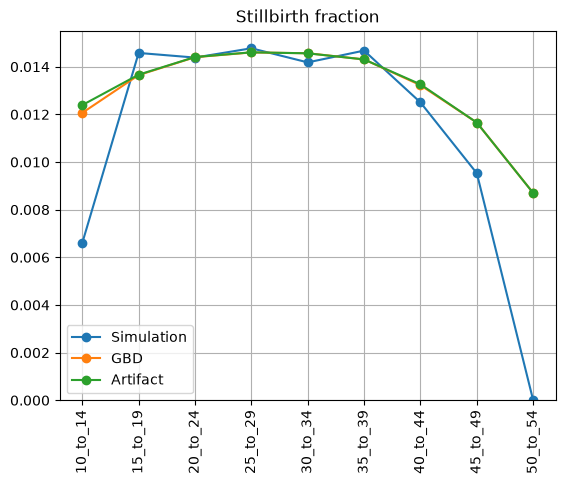

In [8]:
p = outcomes.loc[outcomes.sub_entity=='stillbirth']
plt.plot(p.age_group, p['mean'], marker='o', label='Simulation')
plt.fill_between(p.age_group, p['2.5%'], p['97.5%'], alpha=0.2)

plt.plot(p.age_group.iloc[:9], frac_still.val, marker='o', label='GBD')
plt.plot(p.age_group.iloc[:9], art_still_frac, marker='o', label='Artifact')
plt.title('Stillbirth fraction')
plt.xticks(rotation=90)
plt.legend()
plt.ylim(ymin=0)
plt.grid()

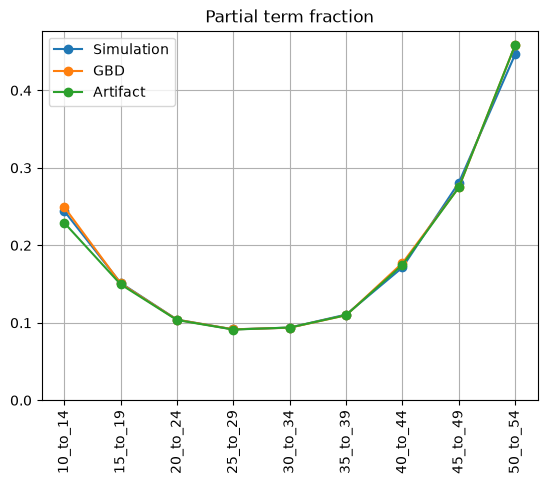

In [9]:
p = outcomes.loc[outcomes.sub_entity=='partial_term']
plt.plot(p.age_group, p['mean'], marker='o', label='Simulation')
plt.fill_between(p.age_group, p['2.5%'], p['97.5%'], alpha=0.2)

plt.plot(p.age_group.iloc[:9], frac_other.val, marker='o', label='GBD')
plt.plot(p.age_group.iloc[:9], art_other_frac, marker='o', label='Artifact')
plt.title('Partial term fraction')
plt.xticks(rotation=90)
plt.legend()
plt.ylim(ymin=0)
plt.grid()

In [10]:
pt = pd.read_parquet(results_dir + 'person_time_pregnancy')
pt.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,person_time,cause,pregnancy,not_pregnant,10_to_14,invalid,1,baseline,0,2,0.0
1,person_time,cause,pregnancy,not_pregnant,10_to_14,invalid,2,baseline,0,2,0.0
2,person_time,cause,pregnancy,not_pregnant,10_to_14,invalid,3,baseline,0,2,0.0
3,person_time,cause,pregnancy,not_pregnant,10_to_14,invalid,4,baseline,0,2,0.0
4,person_time,cause,pregnancy,not_pregnant,10_to_14,invalid,5,baseline,0,2,0.0


In [11]:
preg_transitions = pd.read_parquet(results_dir + 'transition_count_pregnancy')
preg_transitions.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,transition_count,cause,pregnancy,pregnant_to_parturition,10_to_14,invalid,1,baseline,0,2,0.0
1,transition_count,cause,pregnancy,pregnant_to_parturition,10_to_14,invalid,2,baseline,0,2,0.0
2,transition_count,cause,pregnancy,pregnant_to_parturition,10_to_14,invalid,3,baseline,0,2,0.0
3,transition_count,cause,pregnancy,pregnant_to_parturition,10_to_14,invalid,4,baseline,0,2,0.0
4,transition_count,cause,pregnancy,pregnant_to_parturition,10_to_14,invalid,5,baseline,0,2,0.0


In [12]:
assert pt.loc[pt.sub_entity=='not_pregnant']['value'].sum() == 0, "Non-zero person time in the pregnancy state, which is unexpected"

In [13]:
preg_transitions.loc[preg_transitions.scenario=='baseline'].groupby('sub_entity')['value'].sum()

# why are these not 100_000? because they don't include deaths

sub_entity
pregnant_to_parturition       499512.0
parturition_to_postpartum     499512.0
postpartum_to_not_pregnant         0.0
Name: value, dtype: float64

In [14]:
deaths = pd.read_parquet(results_dir + 'deaths')
deaths.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,deaths,cause,other_causes,other_causes,10_to_14,invalid,1,baseline,0,2,0.0
1,deaths,cause,other_causes,other_causes,10_to_14,invalid,2,baseline,0,2,0.0
2,deaths,cause,other_causes,other_causes,10_to_14,invalid,3,baseline,0,2,0.0
3,deaths,cause,other_causes,other_causes,10_to_14,invalid,4,baseline,0,2,0.0
4,deaths,cause,other_causes,other_causes,10_to_14,invalid,5,baseline,0,2,0.0


In [15]:
assert (preg_transitions.loc[preg_transitions.scenario=='baseline'].groupby('sub_entity')['value'].sum()
+ deaths.loc[deaths.scenario=='baseline']['value'].sum()).parturition_to_postpartum == 500_000 * deaths.input_draw.nunique(), "Sum of pregnancy transitions and deaths does not equal expected number of simulants"

In [16]:
assert (preg_transitions.loc[preg_transitions.sub_entity=='parturition_to_postpartum']['value'].sum() 
        == preg_transitions.loc[preg_transitions.sub_entity=='parturition_to_postpartum']['value'].sum()), "Transition counts from preg->parturition do not equal countrs from parturition to postpartum"
assert preg_transitions.loc[preg_transitions.sub_entity=='postpartum_to_not_pregnant']['value'].sum() == 0, "Non-zero transition counts to the not pregnant state"

In [17]:
((pt.loc[pt.sub_entity.isin(['pregnant','parturition'])].groupby('input_draw')['value'].sum() * 365.25/7) 
 / preg_transitions.loc[preg_transitions.sub_entity=='pregnant_to_parturition'].groupby(['input_draw'])['value'].sum()).mean(numeric_only=True)
# average pregnancy duration in weeks
# uniform distribution 6-24 weeks for partial term pregnancies (average 15 weeks)
    # therefore, the weighted AVERAGE population pregnancy duration across 
    # full and partial pregnancy term lengths should be ~30 weeks (15 * 0.4 + 40 * 0.6)
    # which looks right here! Great

36.4289276841263

In [18]:
## This values matches to NO preg model results very closely 

In [19]:
assert np.all(np.isclose(pt.loc[pt.sub_entity=='parturition'].groupby('input_draw')['value'].sum() *365.25/7
        / preg_transitions.loc[preg_transitions.sub_entity=='parturition_to_postpartum'].groupby(['input_draw'])['value'].sum(), 1)), "Time spent in parturition state is different than one week"

assert np.all(pt.loc[pt.sub_entity=='postpartum'].groupby('input_draw')['value'].sum()
 / pt.loc[pt.sub_entity=='parturition'].groupby('input_draw')['value'].sum()), "Postpartum state duration different than expected value of six weeks. Note this test assumes that the duration of the parturition state is confirmed to be one week"

In [20]:
pt_summary = (pt.loc[pt.scenario=='baseline'].groupby(['input_draw','sub_entity'])['value'].sum() / 500_000 * 365 / 7).groupby(['sub_entity']).mean()
pt_summary

sub_entity
not_pregnant     0.000000
pregnant        35.369816
parturition      0.998340
postpartum       5.990041
Name: value, dtype: float64

In [21]:
if deaths.entity.unique != ['maternal_disorders']:
    assert deaths.loc[deaths.entity!='maternal_disorders']['value'].sum() == 0, "Deaths due to causes other than maternal disorders"

In [22]:
pt_frac = (pt.groupby(['input_draw','age_group']).sum() / pt.groupby('input_draw').sum())[['value']].reset_index()
pt_frac.head()

/tmp/ipykernel_1898140/3673599286.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  pt_frac = (pt.groupby(['input_draw','age_group']).sum() / pt.groupby('input_draw').sum())[['value']].reset_index()
/tmp/ipykernel_1898140/3673599286.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  pt_frac = (pt.groupby(['input_draw','age_group']).sum() / pt.groupby('input_draw').sum())[['value']].reset_index()


,input_draw,age_group,value
0,0,10_to_14,0.000859
1,0,15_to_19,0.022315
2,0,20_to_24,0.260930
3,0,25_to_29,0.358746
4,0,30_to_34,0.227358


In [23]:
pop = get_population(release_id=16,
                    location_id=location_id,
                    sex_id=2,
                    age_group_id=age_group_ids,
                    year_id=year_id).rename(columns={'population':'val'})
pop = pop.set_index(['location_id','age_group_id'])[['val']]
pop

val
location_id age_group_id              
163         7             6.286521e+07
            8             6.432311e+07
            9             6.374038e+07
            10            6.159864e+07
            11            5.733795e+07
            12            5.319119e+07
            13            4.683697e+07
            14            3.996526e+07
            15            3.484048e+07
            16            2.993952e+07

In [24]:
pregs = preg_inc * pop
preg_frac = pregs / pregs.groupby('location_id').sum()
preg_frac

val
location_id age_group_id          
163         7             0.001233
            8             0.028473
            9             0.284631
            10            0.355152
            11            0.211550
            12            0.083411
            13            0.027823
            14            0.006986
            15            0.000740
            16            0.000000

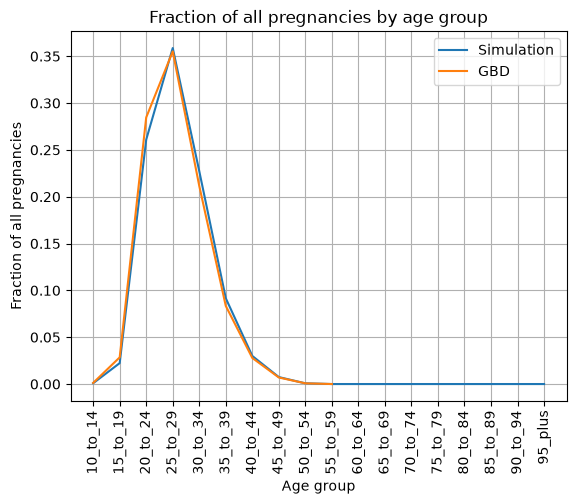

In [25]:
import matplotlib.pyplot as plt
#for draw in pt_frac.input_draw.unique():
#    plt.plot(pt_frac.age.unique(), pt_frac.loc[pt_frac.input_draw==draw]['value'], 
#             alpha=0.5, color='tab:blue')
plt.plot(pt_frac.age_group.unique(), pt_frac.groupby('age_group').mean()[['value']], 
         color='tab:blue', label='Simulation')
plt.plot(pt_frac.age_group.iloc[:10], preg_frac.val, color='tab:orange', label='GBD')
plt.xticks(rotation=90)
plt.title('Fraction of all pregnancies by age group')
plt.grid()
plt.legend()
plt.xlabel('Age group')
plt.ylabel('Fraction of all pregnancies')
plt.show()

# Ok now let's check child data

In [26]:
child_df = pd.read_parquet(results_dir + 'births')
child_df.head()

,maternal_entrance_time,maternal_age,sex,birth_weight,gestational_age,pregnancy_outcome,baseline_2021_iron_consumption_from_fortification_mcg,iron_consumption_from_fortification_mcg,wealth_quintile,scenario,input_draw,random_seed,birth_date
0,2024-12-25,21.006943,Male,94.699994,0.548942,live_birth,0.0,3317.281025,5,baseline,0,2,2024-12-30 T00:00.000000
1,2024-12-25,29.068178,Male,826.732960,0.337788,live_birth,0.0,6171.609778,2,baseline,0,2,2024-12-30 T00:00.000000
2,2024-12-25,29.342459,Male,657.764049,0.687342,live_birth,0.0,0.000000,2,baseline,0,2,2024-12-30 T00:00.000000
3,2024-12-25,37.955906,Female,515.308165,0.029293,live_birth,0.0,0.000000,4,baseline,0,2,2024-12-30 T00:00.000000
4,2024-12-25,28.224721,Male,367.840778,1.329547,live_birth,0.0,19318.188391,2,baseline,0,2,2024-12-30 T00:00.000000


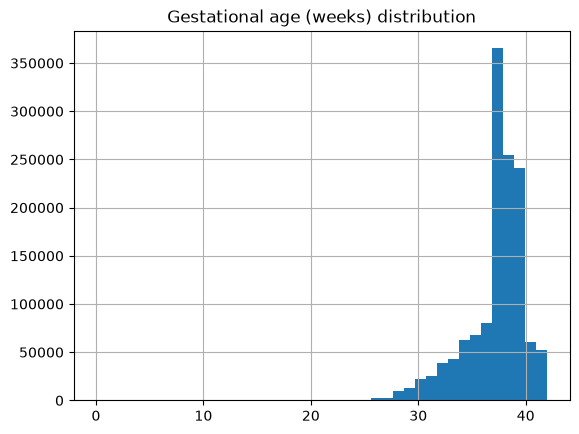

In [27]:
plt.hist(child_df.gestational_age, bins=41)
plt.title('Gestational age (weeks) distribution')
plt.grid()
plt.show()


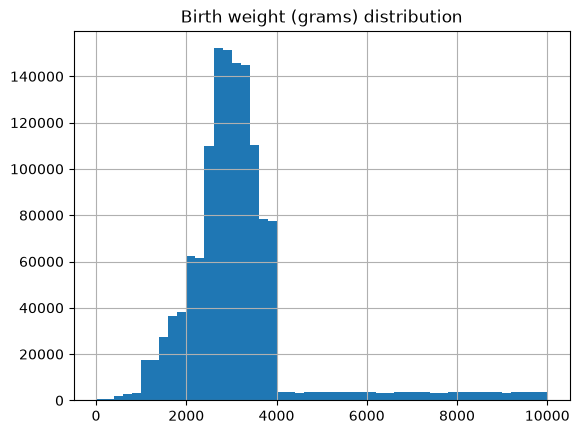

In [28]:
plt.hist(child_df.birth_weight, bins=50)
plt.title('Birth weight (grams) distribution')
plt.grid()
plt.show()


In [29]:
art = artifact.Artifact(artifact_dir)
art_exposure = art.load(f'risk_factor.low_birth_weight_and_short_gestation.exposure')['draw_0'].reset_index()
art_exposure = art_exposure.loc[(art_exposure.sex=='Female')][['parameter']]
art_cats = art.load(f'risk_factor.low_birth_weight_and_short_gestation.categories')
art_exposure['bw_start'] = np.nan
art_exposure['bw_end'] = np.nan
art_exposure['ga_start'] = np.nan
art_exposure['ga_end'] = np.nan
for i in art_exposure.index:
    art_exposure['bw_start'][i] = art_cats[art_exposure.parameter[i]].split('wks, [')[1].split(',')[0]
    art_exposure['bw_end'][i] = art_cats[art_exposure.parameter[i]].split('wks, [')[1].split(', ')[1].split(')')[0]
    art_exposure['ga_start'][i] = art_cats[art_exposure.parameter[i]].split('- [')[1].split(', ')[0]
    art_exposure['ga_end'][i] = art_cats[art_exposure.parameter[i]].split('- [')[1].split(') wks')[0].split(', ')[1]
art_exposure

/tmp/ipykernel_1898140/2996297633.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  art_exposure['bw_start'][i] = art_cats[art_exposure.parameter[i]].split('wks, [')[1].split(',')[0]
/tmp/ipykernel_1898140/2996297633.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  art_exposure['bw_end'][i] = art_cats[art_exposure.parameter[i]].split('wks, [')[1].split(', ')[1].split(')')[0]
/tmp/ipykernel_1898140/2996297633.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#

,parameter,bw_start,bw_end,ga_start,ga_end
0,cat10,500,1000,24,26
1,cat106,1000,1500,36,37
2,cat11,500,1000,26,28
3,cat116,1000,1500,38,40
4,cat117,1500,2000,38,40
5,cat123,1500,2000,40,42+] wks
6,cat124,1000,1500,37,38
7,cat14,500,1000,30,32
8,cat15,500,1000,28,30
9,cat17,1000,1500,26,28


In [30]:
exp = art.load('risk_factor.low_birth_weight_and_short_gestation.exposure')
exp = exp.reset_index()

# for now averaging across sexes because we don't stratify for child data
exp = exp.groupby('parameter').mean()
exp

/tmp/ipykernel_1898140/1639150592.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  exp = exp.groupby('parameter').mean()


,draw_0
parameter,
cat10,0.001242
cat106,0.001515
cat11,0.001242
cat116,0.007479
cat117,0.015884
cat123,0.003355
cat124,0.006743
cat14,0.000734
cat15,0.000945


In [31]:
import re
import pandas as pd

def extract_number(x):
    x = str(x)
    match = re.search(r'\d+', x)
    return int(match.group()) if match else None

art_exposure['ga_start_num'] = art_exposure['ga_start'].apply(extract_number)
art_exposure['ga_end_num'] = art_exposure['ga_end'].apply(extract_number)
art_exposure['bw_start_num'] = art_exposure['bw_start'].apply(extract_number)
art_exposure['bw_end_num'] = art_exposure['bw_end'].apply(extract_number)

In [32]:
cats = pd.Series(np.nan, index=child_df.index, name='parameter')

for i in list(range(0, len(art_exposure))):
    cat = art_exposure.loc[i]

    in_cat = (
        (child_df.gestational_age >= cat.ga_start_num)
        & (child_df.gestational_age < cat.ga_end_num)
        & (child_df.birth_weight >= cat.bw_start_num)
        & (child_df.birth_weight < cat.bw_end_num)
    )

    cats[in_cat] = cat.parameter

cats

0           cat2
1           cat8
2           cat8
3           cat8
4           cat2
           ...  
1345714    cat51
1345715    cat55
1345716    cat55
1345717    cat56
1345718    cat43
Name: parameter, Length: 1345719, dtype: object

In [33]:
child_df_w_cats = pd.concat([child_df, cats], axis=1)
child_df_w_cats

# I am seeing some GAs that are too low...
# they should at least minimize at 6 weeks GA so there is a change to get intervention
# but they are so few that I am not sure if it matters


# we also want sex in the outputs

,maternal_entrance_time,maternal_age,sex,birth_weight,gestational_age,pregnancy_outcome,baseline_2021_iron_consumption_from_fortification_mcg,iron_consumption_from_fortification_mcg,wealth_quintile,scenario,input_draw,random_seed,birth_date,parameter
0,2024-12-25,21.006943,Male,94.699994,0.548942,live_birth,0.0,3317.281025,5,baseline,0,2,2024-12-30 T00:00.000000,cat2
1,2024-12-25,29.068178,Male,826.732960,0.337788,live_birth,0.0,6171.609778,2,baseline,0,2,2024-12-30 T00:00.000000,cat8
2,2024-12-25,29.342459,Male,657.764049,0.687342,live_birth,0.0,0.000000,2,baseline,0,2,2024-12-30 T00:00.000000,cat8
3,2024-12-25,37.955906,Female,515.308165,0.029293,live_birth,0.0,0.000000,4,baseline,0,2,2024-12-30 T00:00.000000,cat8
4,2024-12-25,28.224721,Male,367.840778,1.329547,live_birth,0.0,19318.188391,2,baseline,0,2,2024-12-30 T00:00.000000,cat2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345714,2024-12-25,19.821128,Male,3477.963871,41.831126,live_birth,0.0,1776.807392,5,baseline,0,9,2024-12-30 T00:00.000000,cat51
1345715,2024-12-25,23.849816,Female,3529.367472,41.698823,live_birth,0.0,13410.482533,4,baseline,0,9,2024-12-30 T00:00.000000,cat55
1345716,2024-12-25,31.530624,Male,3915.165949,41.540533,live_birth,0.0,5787.440824,1,baseline,0,9,2024-12-30 T00:00.000000,cat55
1345717,2024-12-25,21.440757,Female,9307.992346,41.773752,live_birth,0.0,0.000000,2,baseline,0,9,2024-12-30 T00:00.000000,cat56


In [34]:
child_df_w_cats['exposure'] = 1
exposure = (child_df_w_cats.groupby(['input_draw','parameter']).exposure.sum() / child_df_w_cats.groupby(['input_draw']).exposure.sum()).reset_index()
exposure

,input_draw,parameter,exposure
0,0,cat10,0.001235
1,0,cat106,0.001462
2,0,cat11,0.001248
3,0,cat116,0.007401
4,0,cat117,0.015801
5,0,cat123,0.003339
6,0,cat124,0.006728
7,0,cat14,0.000733
8,0,cat15,0.000927
9,0,cat17,0.002871


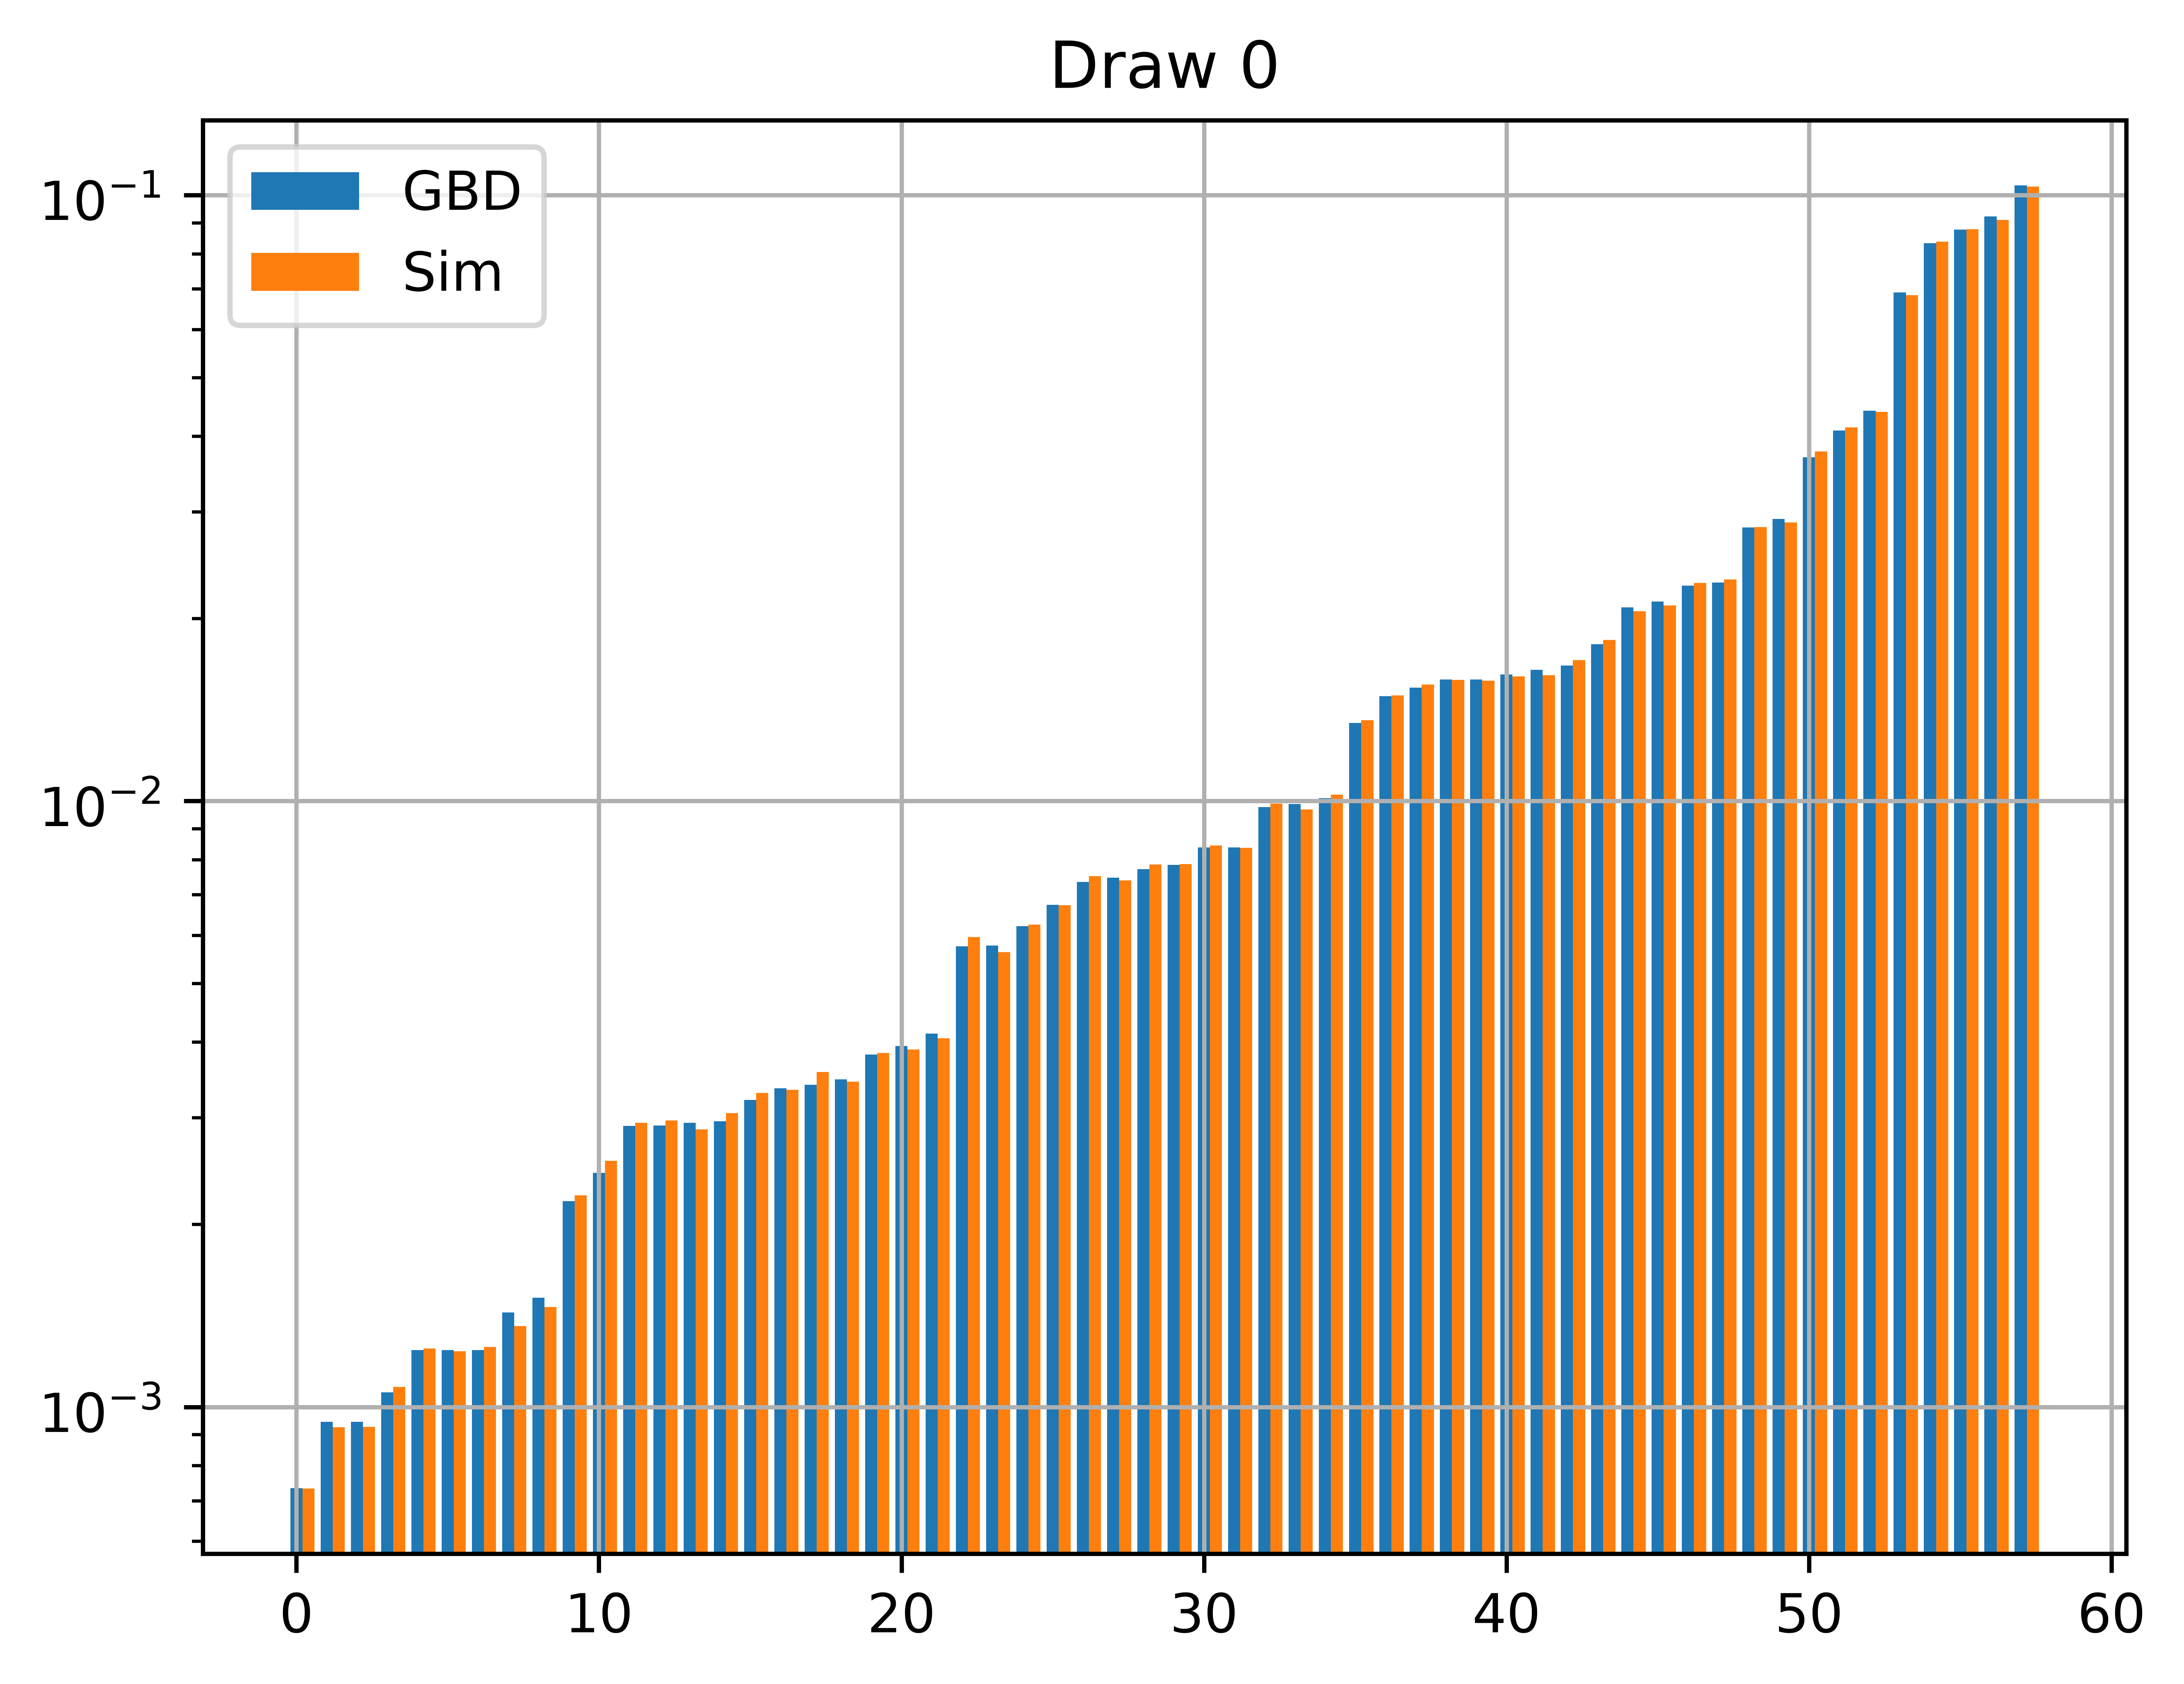

In [35]:
width = 0.4
for draw in exposure.input_draw.unique():
    p = exposure.loc[exposure.input_draw==draw].merge(exp[[f'draw_{draw}']], on='parameter')
    p = p.sort_values(by=f'draw_{draw}').reset_index()
    plt.figure(dpi=1000)
    plt.bar(p.index, p[f'draw_{draw}'], width=width, label='GBD')
    plt.bar(p.index + width, p.exposure, width=width, label='Sim')
    plt.grid()
    plt.legend()
    plt.title(f'Draw {draw}')
    plt.semilogy()

In [36]:
art_data = art_exposure.merge(exp.reset_index(), on='parameter')
#for col in ['bw_start','bw_end','ga_start','ga_end']:
    #art_data[f'{col}'] = art_data[f'{col}'].astype(int)
art_data['bw_mid'] = (art_data.bw_end_num - art_data.bw_start_num) / 2 + art_data.bw_start_num
art_data['ga_mid'] = (art_data.ga_end_num - art_data.ga_start_num) / 2 + art_data.ga_start_num

art_data.head()

,parameter,bw_start,bw_end,ga_start,ga_end,ga_start_num,ga_end_num,bw_start_num,bw_end_num,draw_0,bw_mid,ga_mid
0,cat10,500,1000,24,26,24,26,500,1000,0.001242,750.0,25.0
1,cat106,1000,1500,36,37,36,37,1000,1500,0.001515,1250.0,36.5
2,cat11,500,1000,26,28,26,28,500,1000,0.001242,750.0,27.0
3,cat116,1000,1500,38,40,38,40,1000,1500,0.007479,1250.0,39.0
4,cat117,1500,2000,38,40,38,40,1500,2000,0.015884,1750.0,39.0


In [37]:
for col in ['bw_start', 'bw_end', 'ga_start', 'ga_end']:
    art_data[col] = (
        art_data[col]
        .astype(str)
        .str.extract(r'(\d+)')[0]
        .astype(int)
    )

In [38]:
art_data['bw_mid'] = (art_data.bw_end - art_data.bw_start) / 2 + art_data.bw_start
art_data['ga_mid'] = (art_data.ga_end - art_data.ga_start) / 2 + art_data.ga_start

In [39]:
import seaborn as sns
def plot_exposure_heat_map(draw):
    p = (art_data[['parameter','ga_mid','bw_mid',f'draw_{draw}']]
            .merge(exposure.loc[exposure.input_draw==draw], on=['parameter'], how='left'))
    p = p.replace(np.nan, 0)
    p['diff'] = p[f'draw_{draw}'] - p['exposure']
    p['percent_diff'] = p['diff'] / p[f'draw_{draw}'] * 100

    s = p.pivot_table(index='ga_mid', columns='bw_mid', values=f'draw_{draw}').sort_index(ascending=False)
    s = s.replace(0,np.nan)
    s = np.log(s/(1-s))
    a = p.pivot_table(index='ga_mid', columns='bw_mid', values='percent_diff').sort_index(ascending=False)
    a = a.replace(0,np.nan)
    #a=np.log(a/(1-a))
    fig, (ax1, ax2) = plt.subplots(1,2, dpi=200)
    sns.heatmap(s, ax=ax1,annot=True,cmap="coolwarm",vmin=-11,vmax=-1.5)
    sns.heatmap(a, ax=ax2,annot=True,cmap="coolwarm",vmin=-20,vmax=20)
    ax1.set_title('Logit-transformed exposure\ndistribution from artifact')
    ax2.set_title('Simulation exposure relative\nto artifact percent difference')
    for ax in [ax1,ax2]:
        ax.set_xlabel('Birthweight midpoint (g)')
        ax.set_ylabel('Gestational age midpoint (weeks)')
    plt.subplots_adjust(right=1.8, top=1)    
    plt.suptitle(f'Draw {draw}',
                x=0.9, y=1.25)

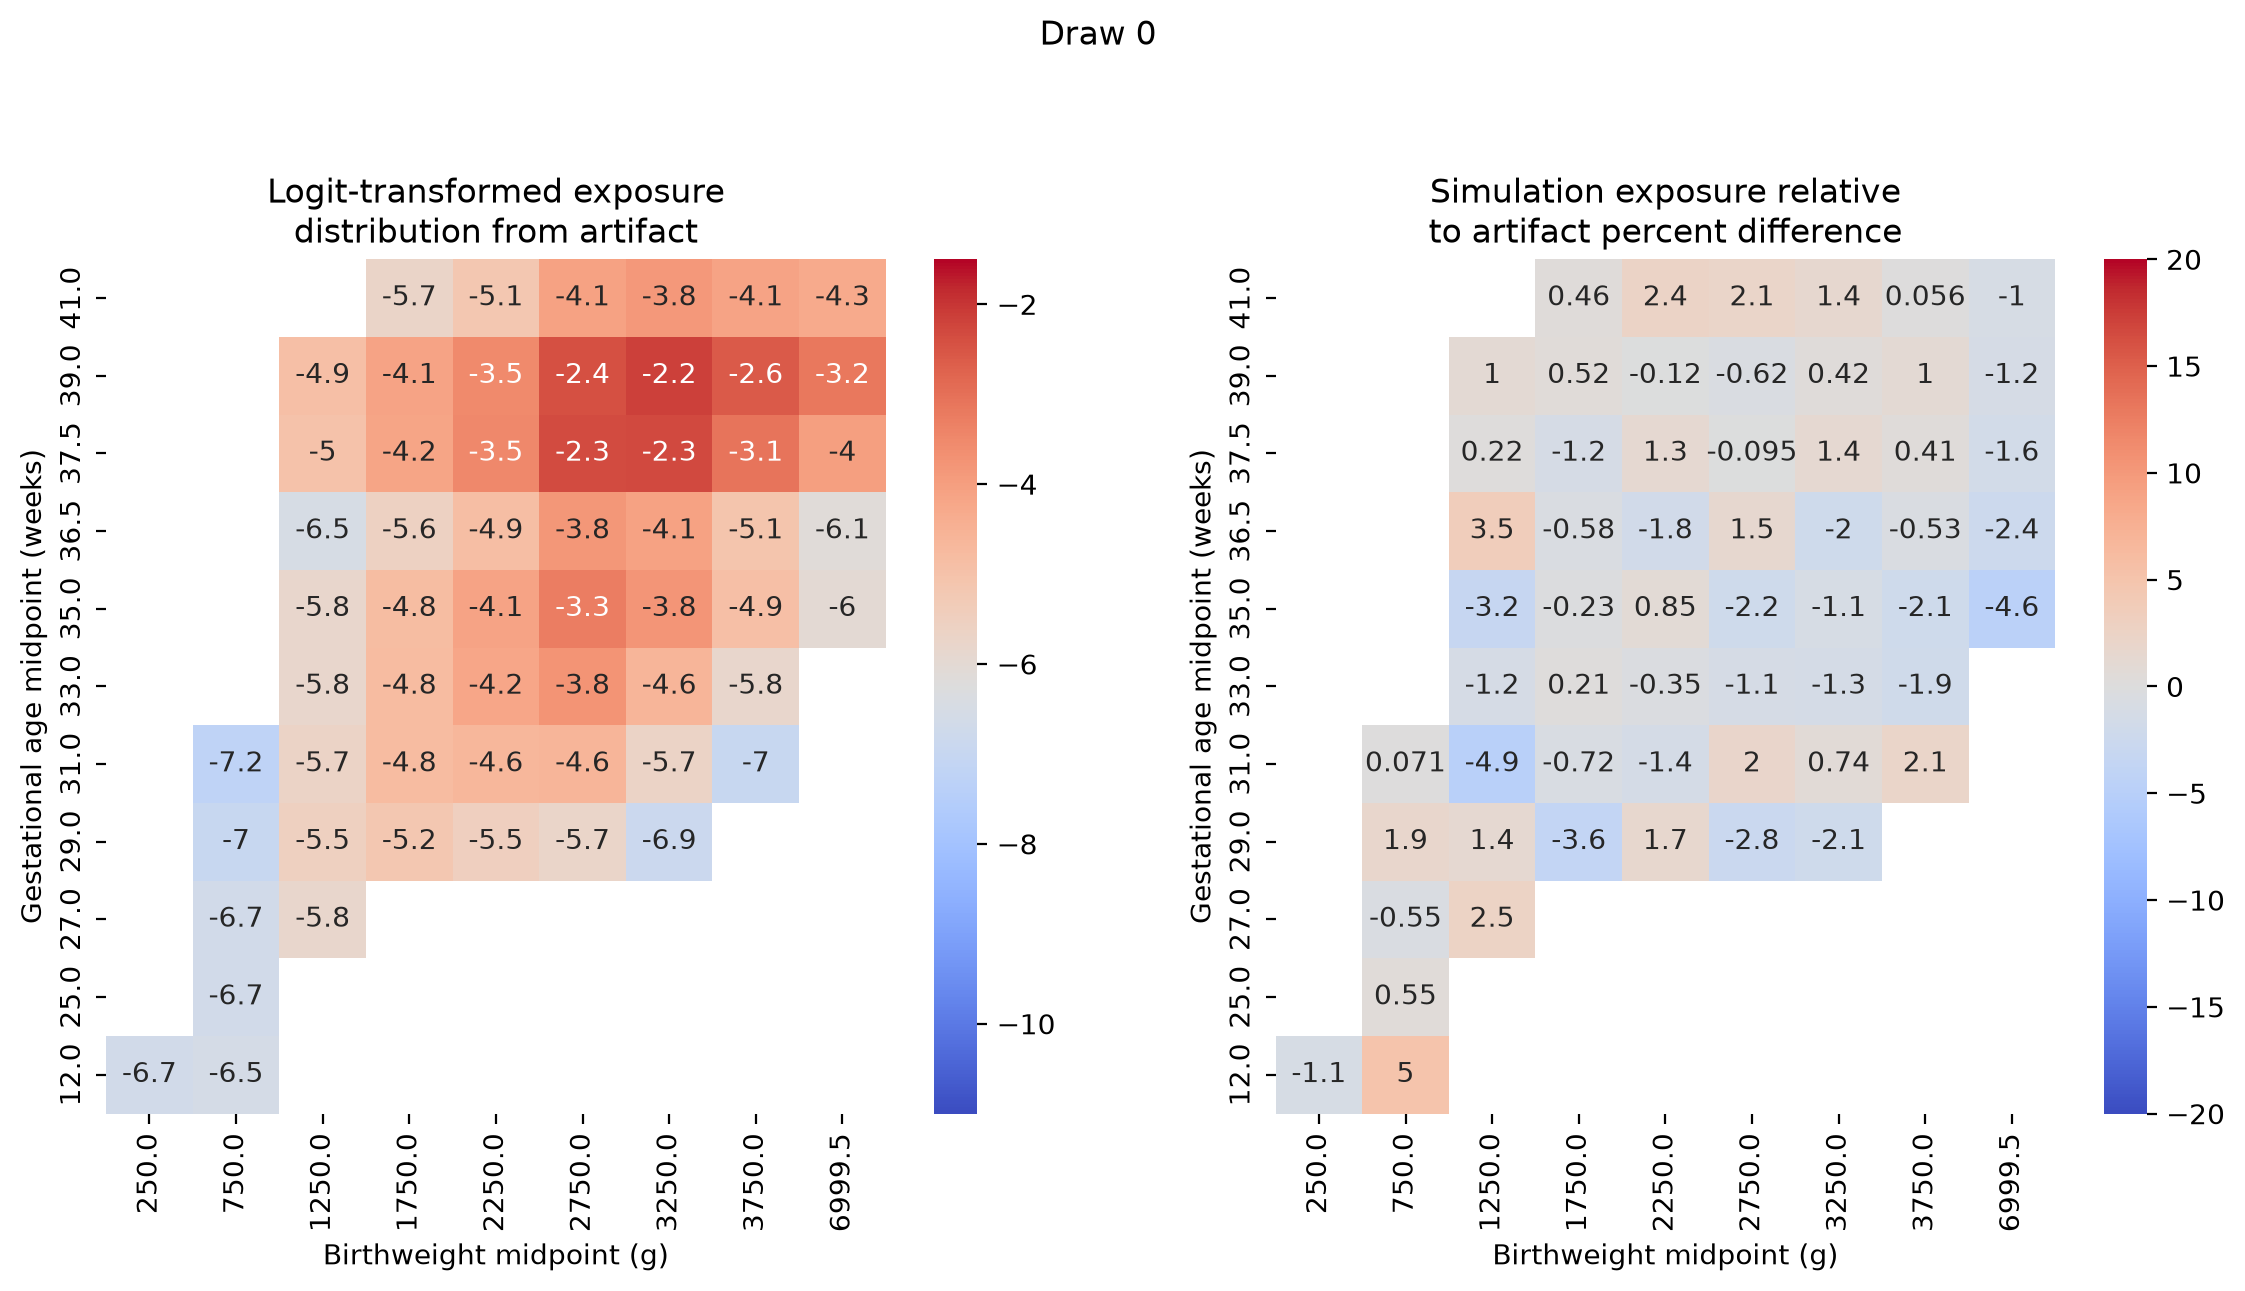

In [40]:
for draw in exposure.input_draw.unique():
    plot_exposure_heat_map(draw)

# some notes on the interpretation of these plots:
    # in the righthand subplot, we expect to see DARK red and blue on the edges of the distribution that have low overall exposure and are therefore subject to more stochastic uncertainty
        # if we are seeing dark colors (big differences) in the categories on the right subplot for the categories with higher exposure (darker red in the lefthand plot), thise would be unexpected

    # we also do not want to see any noticable trend/pattern in color (blue versus red) that would indicate a systematic over or underestimation 

## Added V&V: denominator and linkage sanity

Cheap guards against the "empty run succeeds" failure class. The population-size assert
earlier in this notebook covers totals; these check per-seed plausibility and that the
births line list (the child sim's input) agrees with the outcome counts.

In [41]:
outcomes = pd.read_parquet(results_dir + "pregnancy_outcome_count")
per_seed = outcomes.groupby(["scenario", "input_draw", "random_seed"]).value.sum()
assert ((per_seed > 1_000) & (per_seed < 1_000_000)).all(), per_seed.describe()

lb = outcomes[outcomes.sub_entity == "live_birth"].groupby("scenario").value.sum()
line_list = pd.read_parquet(results_dir + "births")
ll = line_list[line_list.pregnancy_outcome == "live_birth"].groupby("scenario").size()
assert (lb == ll).all(), pd.DataFrame({"outcome_count": lb, "line_list": ll})
print(f"outcomes per seed: {int(per_seed.min()):,} - {int(per_seed.max()):,} | "
      f"live births match the line list in all scenarios ({int(lb.sum()):,} total)")

outcomes per seed: 50,000 - 50,000 | live births match the line list in all scenarios (1,324,113 total)
